#  Phase 5: Model Building

## 🧩 Tasks Checklist:
- [x] **Step 5.1**: Setup experiments
- [x] **Step 5.2**: Run all 27 experiments (3 scalers × 3 feature sets × 3 models)
- [x] **Step 5.3**: Analyze results by variable
- [x] **Step 5.4**: Evaluate best model on test set
- [x] **Step 5.5**: Final summary and conclusions

## 📋 Experiment Design:
| Variable | Options |
|----------|--------|
| Scalers | StandardScaler, MinMaxScaler, None |
| Feature Sets | All 29, Top 15, Top 10 |
| Models | Logistic Regression, Decision Tree, Random Forest |
| Validation | 5-Fold Stratified Cross-Validation |

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, auc)
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(" Libraries imported successfully!")
print(f"📅 Analysis started on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

 Libraries imported successfully!
📅 Analysis started on: 2025-12-01 13:57:36


---
## 🔧 Step 5.1: Setup Experiments

**Goal**: Load data and define experiment variables

In [2]:
# Load the raw dataset
data_path = "../data/raw/Electronic_sales_Sep2023-Sep2024.csv"  # Adjust path as needed
df = pd.read_csv(data_path)

print(" Data loaded successfully!")
print(f" Dataset shape: {df.shape}")

 Data loaded successfully!
 Dataset shape: (20000, 16)


In [3]:
# Apply preprocessing (same as Phase 3)
print("🔄 Applying preprocessing...")

# Handle missing values
df['Gender'] = df['Gender'].fillna('Male')
df['Add-ons Purchased'] = df['Add-ons Purchased'].fillna('None')

# Fix inconsistencies
df['Payment Method'] = df['Payment Method'].replace('Paypal', 'PayPal')

# Convert date
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Feature engineering
df['Purchase_Month'] = df['Purchase Date'].dt.month
df['Purchase_DayOfWeek'] = df['Purchase Date'].dt.dayofweek
df['Is_Weekend'] = (df['Purchase_DayOfWeek'] >= 5).astype(int)
df['Has_Addon'] = (df['Add-on Total'] > 0).astype(int)
df['Addon_Count'] = df['Add-ons Purchased'].apply(lambda x: 0 if x == 'None' else len(str(x).split(',')))

# Repeat customer
customer_counts = df['Customer ID'].value_counts()
repeat_customers = customer_counts[customer_counts > 1].index
df['Is_Repeat_Customer'] = df['Customer ID'].isin(repeat_customers).astype(int)

# Encode target
df['Order Status'] = df['Order Status'].map({'Completed': 1, 'Cancelled': 0})

# Encode categorical
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Loyalty Member'] = df['Loyalty Member'].map({'Yes': 1, 'No': 0})

# One-hot encode
df = pd.get_dummies(df, columns=['Product Type', 'Payment Method', 'Shipping Type'], 
                    prefix=['Product', 'Payment', 'Shipping'])

# Drop non-features
df = df.drop(columns=['Customer ID', 'SKU', 'Add-ons Purchased', 'Purchase Date'])

# Cap outliers
for col in ['Total Price', 'Add-on Total']:
    p1, p99 = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col] = df[col].clip(lower=p1, upper=p99)

print(" Preprocessing complete!")
print(f" Final shape: {df.shape}")

🔄 Applying preprocessing...
 Preprocessing complete!
 Final shape: (20000, 30)


In [4]:
# Prepare X and y
X = df.drop(columns=['Order Status'])
y = df['Order Status']

# Define feature sets based on RF importance (from Phase 4)
top_10_features = ['Age', 'Add-on Total', 'Purchase_Month', 'Total Price', 'Quantity', 
                   'Purchase_DayOfWeek', 'Rating', 'Addon_Count', 'Unit Price', 'Gender']

top_15_features = top_10_features + ['Is_Repeat_Customer', 'Loyalty Member', 
                                      'Shipping_Standard', 'Payment_PayPal', 'Payment_Credit Card']

# Columns to scale (numerical only)
cols_to_scale = ['Age', 'Rating', 'Total Price', 'Unit Price', 'Quantity', 
                 'Add-on Total', 'Purchase_Month', 'Purchase_DayOfWeek', 'Addon_Count']

print("="*70)
print("EXPERIMENT SETUP")
print("="*70)
print(f"\n Dataset: {X.shape[0]} records, {X.shape[1]} features")
print(f" Target: Order Status (Completed=1: {(y==1).sum()}, Cancelled=0: {(y==0).sum()})")
print(f"\n📋 Feature Sets:")
print(f"   • All_29: {len(X.columns)} features")
print(f"   • Top_15: {len(top_15_features)} features")
print(f"   • Top_10: {len(top_10_features)} features")
print(f"\n📋 Scalers: StandardScaler, MinMaxScaler, None")
print(f"📋 Models: Logistic Regression, Decision Tree, Random Forest")
print(f"📋 Validation: 5-Fold Stratified Cross-Validation")
print(f"\n📋 Total experiments: 3 × 3 × 3 = 27")

EXPERIMENT SETUP

 Dataset: 20000 records, 29 features
 Target: Order Status (Completed=1: 13432, Cancelled=0: 6568)

📋 Feature Sets:
   • All_29: 29 features
   • Top_15: 15 features
   • Top_10: 10 features

📋 Scalers: StandardScaler, MinMaxScaler, None
📋 Models: Logistic Regression, Decision Tree, Random Forest
📋 Validation: 5-Fold Stratified Cross-Validation

📋 Total experiments: 3 × 3 × 3 = 27


---
## 🔬 Step 5.2: Run All 27 Experiments

**Goal**: Test all combinations of scalers, feature sets, and models using 5-fold cross-validation

In [5]:
# Define experiment configurations
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'None': None
}

feature_sets = {
    'All_29': X.columns.tolist(),
    'Top_15': top_15_features,
    'Top_10': top_10_features
}

models = {
    'Logistic_Regression': LogisticRegression(
        random_state=42, 
        class_weight='balanced', 
        max_iter=1000
    ),
    'Decision_Tree': DecisionTreeClassifier(
        random_state=42, 
        class_weight='balanced', 
        max_depth=10, 
        min_samples_split=20, 
        min_samples_leaf=10
    ),
    'Random_Forest': RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        class_weight='balanced', 
        max_depth=15, 
        min_samples_split=10, 
        min_samples_leaf=5, 
        n_jobs=-1
    )
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(" Experiment configurations defined")
print(f"   • Scalers: {list(scalers.keys())}")
print(f"   • Feature sets: {list(feature_sets.keys())}")
print(f"   • Models: {list(models.keys())}")

 Experiment configurations defined
   • Scalers: ['StandardScaler', 'MinMaxScaler', 'None']
   • Feature sets: ['All_29', 'Top_15', 'Top_10']
   • Models: ['Logistic_Regression', 'Decision_Tree', 'Random_Forest']


In [7]:
# Run all 27 experiments
print("="*70)
print("RUNNING 27 EXPERIMENTS (5-Fold CV each)")
print("="*70)

results = []
exp_num = 0

for scaler_name, scaler in scalers.items():
    for feature_name, features in feature_sets.items():
        # Prepare feature set
        X_subset = X[features].copy()
        
        # Apply scaling
        if scaler is not None:
            scaler_instance = scaler.__class__()  # Fresh instance
            scale_cols = [c for c in cols_to_scale if c in features]
            X_subset[scale_cols] = scaler_instance.fit_transform(X_subset[scale_cols])
        
        for model_name, model in models.items():
            exp_num += 1
            model_instance = model.__class__(**model.get_params())  # Fresh instance
            
            # Cross-validation scores
            cv_accuracy = cross_val_score(model_instance, X_subset, y, cv=cv, scoring='accuracy')
            cv_f1 = cross_val_score(model_instance, X_subset, y, cv=cv, scoring='f1')
            cv_roc_auc = cross_val_score(model_instance, X_subset, y, cv=cv, scoring='roc_auc')
            cv_precision = cross_val_score(model_instance, X_subset, y, cv=cv, scoring='precision')
            cv_recall = cross_val_score(model_instance, X_subset, y, cv=cv, scoring='recall')
            
            results.append({
                'Experiment': exp_num,
                'Scaler': scaler_name,
                'Features': feature_name,
                'Model': model_name,
                'Accuracy_Mean': cv_accuracy.mean(),
                'Accuracy_Std': cv_accuracy.std(),
                'F1_Mean': cv_f1.mean(),
                'F1_Std': cv_f1.std(),
                'ROC_AUC_Mean': cv_roc_auc.mean(),
                'ROC_AUC_Std': cv_roc_auc.std(),
                'Precision_Mean': cv_precision.mean(),
                'Recall_Mean': cv_recall.mean()
            })
            
            print(f"   [{exp_num:2}/27] {scaler_name:<15} + {feature_name:<8} + {model_name:<22} → Acc: {cv_accuracy.mean()*100:.2f}%, F1: {cv_f1.mean()*100:.2f}%")

# Create results dataframe
results_df = pd.DataFrame(results)

print("\n All 27 experiments complete!")

RUNNING 27 EXPERIMENTS (5-Fold CV each)
   [ 1/27] StandardScaler  + All_29   + Logistic_Regression    → Acc: 50.54%, F1: 57.92%
   [ 2/27] StandardScaler  + All_29   + Decision_Tree          → Acc: 48.75%, F1: 54.74%
   [ 3/27] StandardScaler  + All_29   + Random_Forest          → Acc: 61.09%, F1: 73.97%
   [ 4/27] StandardScaler  + Top_15   + Logistic_Regression    → Acc: 49.97%, F1: 57.15%
   [ 5/27] StandardScaler  + Top_15   + Decision_Tree          → Acc: 50.92%, F1: 58.91%
   [ 6/27] StandardScaler  + Top_15   + Random_Forest          → Acc: 61.34%, F1: 74.34%
   [ 7/27] StandardScaler  + Top_10   + Logistic_Regression    → Acc: 49.52%, F1: 57.07%
   [ 8/27] StandardScaler  + Top_10   + Decision_Tree          → Acc: 50.68%, F1: 58.78%
   [ 9/27] StandardScaler  + Top_10   + Random_Forest          → Acc: 60.15%, F1: 72.88%
   [10/27] MinMaxScaler    + All_29   + Logistic_Regression    → Acc: 50.51%, F1: 57.90%
   [11/27] MinMaxScaler    + All_29   + Decision_Tree          → Acc: 

In [8]:
# Save experiment results
results_df.to_csv('../data/processed/experiment_results.csv', index=False)
print("💾 Saved: experiment_results.csv")

# Display all results
print("\n ALL EXPERIMENT RESULTS:")
display(results_df[['Experiment', 'Scaler', 'Features', 'Model', 
                    'Accuracy_Mean', 'F1_Mean', 'ROC_AUC_Mean']].round(4))

💾 Saved: experiment_results.csv

 ALL EXPERIMENT RESULTS:


,Experiment,Scaler,Features,Model,Accuracy_Mean,F1_Mean,ROC_AUC_Mean
0,1,StandardScaler,All_29,Logistic_Regression,0.5054,0.5792,0.5019
1,2,StandardScaler,All_29,Decision_Tree,0.4876,0.5474,0.4989
2,3,StandardScaler,All_29,Random_Forest,0.6108,0.7397,0.4927
3,4,StandardScaler,Top_15,Logistic_Regression,0.4996,0.5715,0.4984
4,5,StandardScaler,Top_15,Decision_Tree,0.5092,0.5891,0.4984
5,6,StandardScaler,Top_15,Random_Forest,0.6134,0.7434,0.4941
6,7,StandardScaler,Top_10,Logistic_Regression,0.4952,0.5707,0.4889
7,8,StandardScaler,Top_10,Decision_Tree,0.5068,0.5878,0.4982
8,9,StandardScaler,Top_10,Random_Forest,0.6015,0.7288,0.4928
9,10,MinMaxScaler,All_29,Logistic_Regression,0.5050,0.5790,0.5024


---
##  Step 5.3: Analyze Results by Variable

**Goal**: Understand impact of each variable (scaler, features, model) on performance

In [9]:
# Sort by F1 score
results_sorted = results_df.sort_values('F1_Mean', ascending=False)

print("="*70)
print("TOP 10 EXPERIMENTS (by F1-Score)")
print("="*70)
print(f"{'Rank':<5} {'Scaler':<15} {'Features':<10} {'Model':<22} {'Acc%':<8} {'F1%':<8} {'AUC%':<8}")
print("-"*70)

for i, (_, row) in enumerate(results_sorted.head(10).iterrows(), 1):
    print(f"{i:<5} {row['Scaler']:<15} {row['Features']:<10} {row['Model']:<22} {row['Accuracy_Mean']*100:<8.2f} {row['F1_Mean']*100:<8.2f} {row['ROC_AUC_Mean']*100:<8.2f}")

TOP 10 EXPERIMENTS (by F1-Score)
Rank  Scaler          Features   Model                  Acc%     F1%      AUC%    
----------------------------------------------------------------------
1     MinMaxScaler    Top_15     Random_Forest          61.42    74.40    49.41   
2     None            Top_15     Random_Forest          61.37    74.35    49.40   
3     StandardScaler  Top_15     Random_Forest          61.34    74.34    49.41   
4     StandardScaler  All_29     Random_Forest          61.09    73.97    49.27   
5     MinMaxScaler    All_29     Random_Forest          61.07    73.96    49.26   
6     None            All_29     Random_Forest          61.03    73.93    49.26   
7     MinMaxScaler    Top_10     Random_Forest          60.21    72.92    49.29   
8     None            Top_10     Random_Forest          60.17    72.90    49.29   
9     StandardScaler  Top_10     Random_Forest          60.15    72.88    49.28   
10    StandardScaler  Top_15     Decision_Tree          50.92    5


ANALYSIS BY SCALER

 Average Performance by Scaler:
--------------------------------------------------
   MinMaxScaler    → Acc: 53.71%, F1: 62.91%, AUC: 49.62%
   StandardScaler  → Acc: 53.66%, F1: 62.86%, AUC: 49.60%
   None            → Acc: 53.52%, F1: 62.63%, AUC: 49.61%


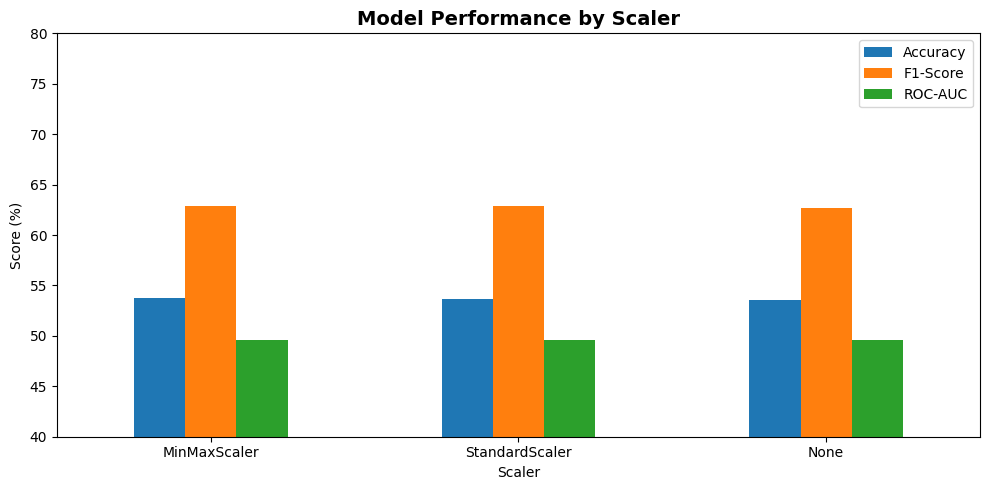


💾 Saved: performance_by_scaler.png


In [10]:
# Analysis by Scaler
print("\n" + "="*70)
print("ANALYSIS BY SCALER")
print("="*70)

scaler_perf = results_df.groupby('Scaler')[['Accuracy_Mean', 'F1_Mean', 'ROC_AUC_Mean']].mean()
scaler_perf = scaler_perf.sort_values('F1_Mean', ascending=False)

print("\n Average Performance by Scaler:")
print("-"*50)
for scaler, row in scaler_perf.iterrows():
    print(f"   {scaler:<15} → Acc: {row['Accuracy_Mean']*100:.2f}%, F1: {row['F1_Mean']*100:.2f}%, AUC: {row['ROC_AUC_Mean']*100:.2f}%")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
scaler_perf_pct = scaler_perf * 100
scaler_perf_pct.plot(kind='bar', ax=ax, rot=0)
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance by Scaler', fontsize=14, fontweight='bold')
ax.legend(['Accuracy', 'F1-Score', 'ROC-AUC'])
ax.set_ylim([40, 80])
plt.tight_layout()
plt.savefig('../outputs/figures/performance_by_scaler.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Saved: performance_by_scaler.png")


ANALYSIS BY FEATURE SET

 Average Performance by Feature Set:
--------------------------------------------------
   Top_15          → Acc: 54.08%, F1: 63.46%, AUC: 49.70%
   Top_10          → Acc: 53.40%, F1: 62.80%, AUC: 49.35%
   All_29          → Acc: 53.41%, F1: 62.15%, AUC: 49.80%


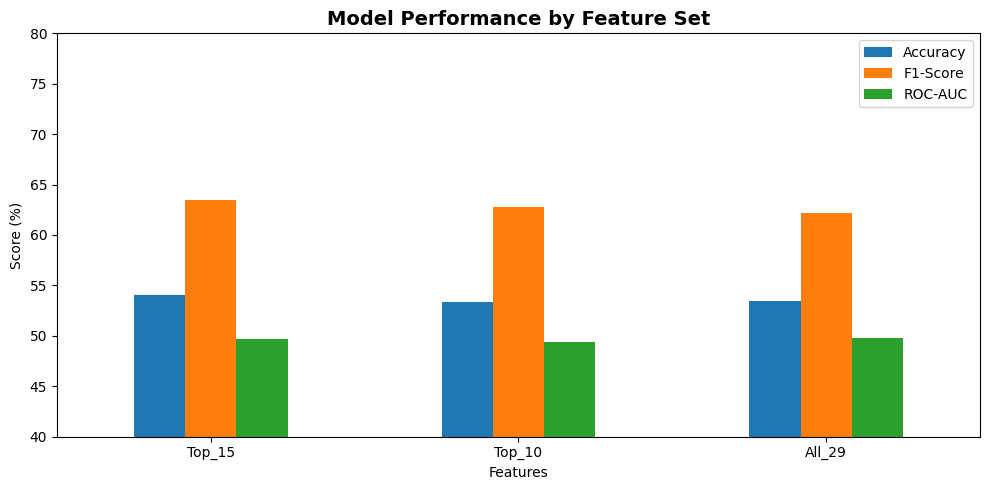


💾 Saved: performance_by_features.png


In [11]:
# Analysis by Feature Set
print("\n" + "="*70)
print("ANALYSIS BY FEATURE SET")
print("="*70)

feature_perf = results_df.groupby('Features')[['Accuracy_Mean', 'F1_Mean', 'ROC_AUC_Mean']].mean()
feature_perf = feature_perf.sort_values('F1_Mean', ascending=False)

print("\n Average Performance by Feature Set:")
print("-"*50)
for feat, row in feature_perf.iterrows():
    print(f"   {feat:<15} → Acc: {row['Accuracy_Mean']*100:.2f}%, F1: {row['F1_Mean']*100:.2f}%, AUC: {row['ROC_AUC_Mean']*100:.2f}%")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
feature_perf_pct = feature_perf * 100
feature_perf_pct.plot(kind='bar', ax=ax, rot=0)
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance by Feature Set', fontsize=14, fontweight='bold')
ax.legend(['Accuracy', 'F1-Score', 'ROC-AUC'])
ax.set_ylim([40, 80])
plt.tight_layout()
plt.savefig('../outputs/figures/performance_by_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Saved: performance_by_features.png")


ANALYSIS BY MODEL

 Average Performance by Model:
--------------------------------------------------
   Random_Forest          → Acc: 60.87%, F1: 73.74%, AUC: 49.32%
   Decision_Tree          → Acc: 50.11%, F1: 57.48%, AUC: 49.85%
   Logistic_Regression    → Acc: 49.90%, F1: 57.19%, AUC: 49.67%


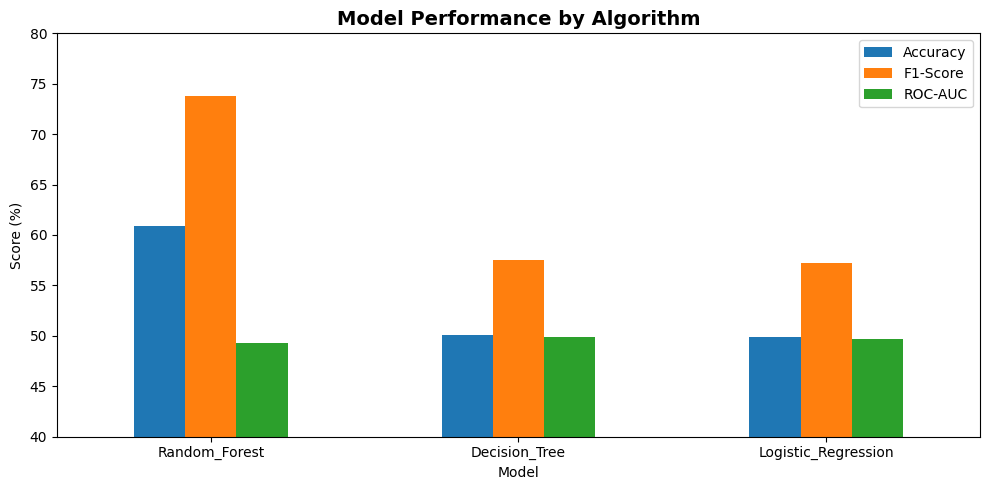


💾 Saved: performance_by_model.png


In [12]:
# Analysis by Model
print("\n" + "="*70)
print("ANALYSIS BY MODEL")
print("="*70)

model_perf = results_df.groupby('Model')[['Accuracy_Mean', 'F1_Mean', 'ROC_AUC_Mean']].mean()
model_perf = model_perf.sort_values('F1_Mean', ascending=False)

print("\n Average Performance by Model:")
print("-"*50)
for model, row in model_perf.iterrows():
    print(f"   {model:<22} → Acc: {row['Accuracy_Mean']*100:.2f}%, F1: {row['F1_Mean']*100:.2f}%, AUC: {row['ROC_AUC_Mean']*100:.2f}%")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
model_perf_pct = model_perf * 100
model_perf_pct.plot(kind='bar', ax=ax, rot=0)
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance by Algorithm', fontsize=14, fontweight='bold')
ax.legend(['Accuracy', 'F1-Score', 'ROC-AUC'])
ax.set_ylim([40, 80])
plt.tight_layout()
plt.savefig('../outputs/figures/performance_by_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Saved: performance_by_model.png")


F1-SCORE HEATMAP


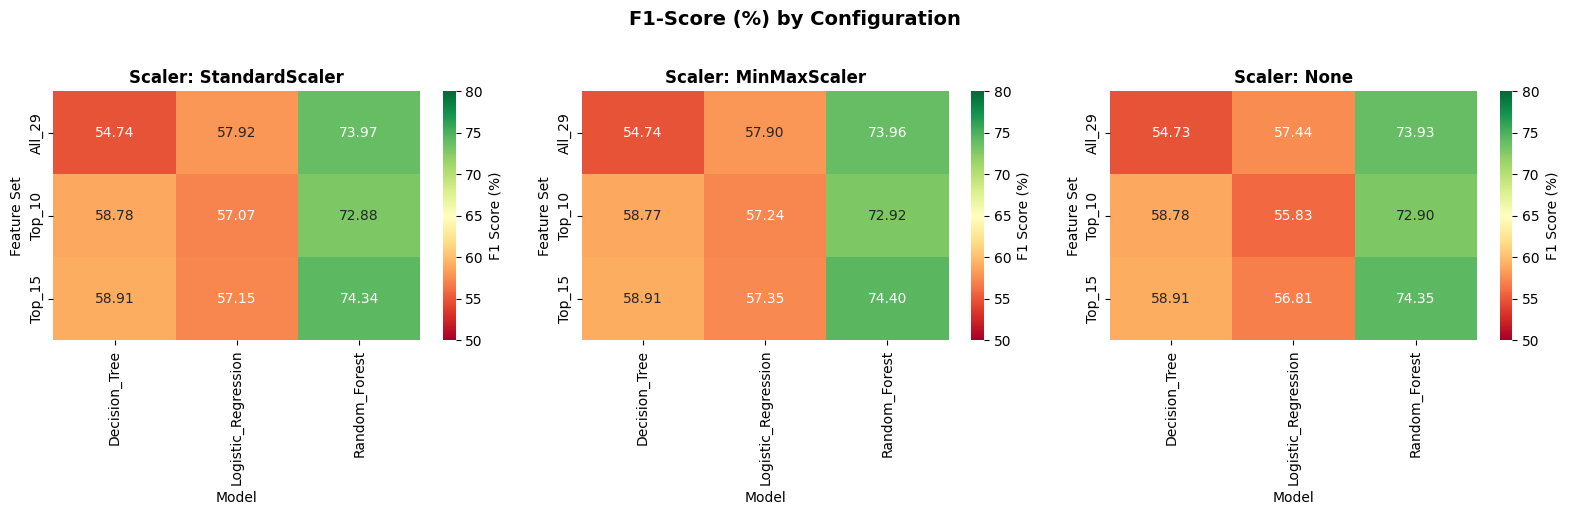


💾 Saved: f1_score_heatmap.png


In [13]:
# Heatmap of F1 scores
print("\n" + "="*70)
print("F1-SCORE HEATMAP")
print("="*70)

# Create pivot tables for each scaler
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, scaler_name in enumerate(['StandardScaler', 'MinMaxScaler', 'None']):
    subset = results_df[results_df['Scaler'] == scaler_name]
    pivot = subset.pivot(index='Features', columns='Model', values='F1_Mean') * 100
    
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', 
                ax=axes[idx], vmin=50, vmax=80, cbar_kws={'label': 'F1 Score (%)'})
    axes[idx].set_title(f'Scaler: {scaler_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Model')
    axes[idx].set_ylabel('Feature Set')

plt.suptitle('F1-Score (%) by Configuration', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/f1_score_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Saved: f1_score_heatmap.png")

---
## 🏆 Step 5.4: Evaluate Best Model on Test Set

**Best Configuration**: MinMaxScaler + Top 15 Features + Random Forest

In [14]:
# Identify best configuration
best_config = results_sorted.iloc[0]

print("="*70)
print("🏆 BEST MODEL CONFIGURATION")
print("="*70)
print(f"\n   • Scaler: {best_config['Scaler']}")
print(f"   • Features: {best_config['Features']}")
print(f"   • Model: {best_config['Model']}")
print(f"   • CV Accuracy: {best_config['Accuracy_Mean']*100:.2f}% (±{best_config['Accuracy_Std']*100:.2f}%)")
print(f"   • CV F1-Score: {best_config['F1_Mean']*100:.2f}% (±{best_config['F1_Std']*100:.2f}%)")
print(f"   • CV ROC-AUC: {best_config['ROC_AUC_Mean']*100:.2f}% (±{best_config['ROC_AUC_Std']*100:.2f}%)")

🏆 BEST MODEL CONFIGURATION

   • Scaler: MinMaxScaler
   • Features: Top_15
   • Model: Random_Forest
   • CV Accuracy: 61.42% (±0.69%)
   • CV F1-Score: 74.40% (±0.50%)
   • CV ROC-AUC: 49.41% (±1.12%)


In [15]:
# Prepare data with best configuration
X_best = X[top_15_features].copy()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_best, y, test_size=0.20, random_state=42, stratify=y
)

# Apply MinMaxScaler
scale_cols = [c for c in cols_to_scale if c in top_15_features]
scaler = MinMaxScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

print(f" Training set: {X_train.shape}")
print(f" Test set: {X_test.shape}")

 Training set: (16000, 15)
 Test set: (4000, 15)


In [16]:
# Train final model
print("\n🔄 Training final Random Forest model...")

best_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42, 
    class_weight='balanced',
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1
)
best_model.fit(X_train, y_train)

print(" Training complete!")


🔄 Training final Random Forest model...
 Training complete!


In [17]:
# Predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Calculate metrics
print("\n" + "="*70)
print("FINAL MODEL PERFORMANCE (Test Set)")
print("="*70)

print(f"\n METRICS:")
print("-"*50)
print(f"   Accuracy:  {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"   Precision: {precision_score(y_test, y_pred)*100:.2f}%")
print(f"   Recall:    {recall_score(y_test, y_pred)*100:.2f}%")
print(f"   F1-Score:  {f1_score(y_test, y_pred)*100:.2f}%")
print(f"   ROC-AUC:   {roc_auc_score(y_test, y_prob)*100:.2f}%")


FINAL MODEL PERFORMANCE (Test Set)

 METRICS:
--------------------------------------------------
   Accuracy:  61.65%
   Precision: 66.91%
   Recall:    84.85%
   F1-Score:  74.82%
   ROC-AUC:   48.76%



 CONFUSION MATRIX:


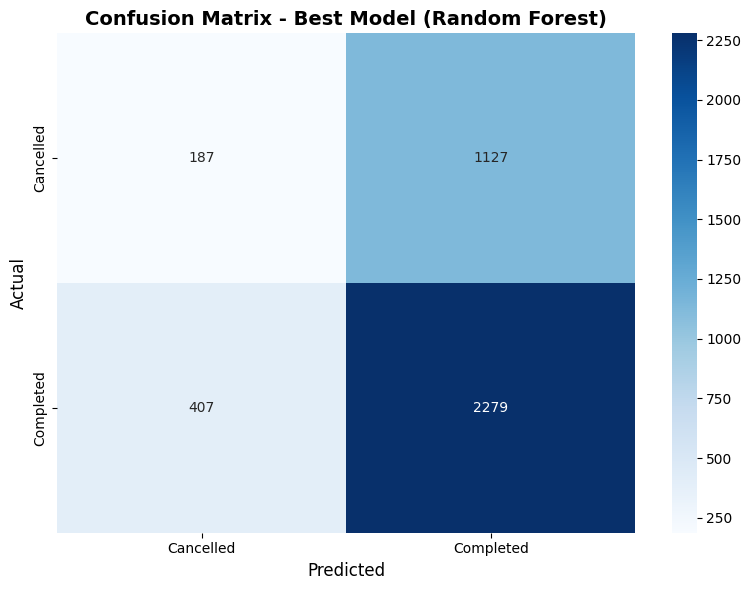


   True Negative (Cancelled→Cancelled):  187
   False Positive (Cancelled→Completed): 1127
   False Negative (Completed→Cancelled): 407
   True Positive (Completed→Completed):  2279

💾 Saved: confusion_matrix_best_model.png


In [18]:
# Confusion Matrix
print("\n CONFUSION MATRIX:")
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Cancelled', 'Completed'],
            yticklabels=['Cancelled', 'Completed'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix - Best Model (Random Forest)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n   True Negative (Cancelled→Cancelled):  {cm[0,0]}")
print(f"   False Positive (Cancelled→Completed): {cm[0,1]}")
print(f"   False Negative (Completed→Cancelled): {cm[1,0]}")
print(f"   True Positive (Completed→Completed):  {cm[1,1]}")

print("\n💾 Saved: confusion_matrix_best_model.png")

In [19]:
# Classification Report
print("\n CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Cancelled', 'Completed']))


 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

   Cancelled       0.31      0.14      0.20      1314
   Completed       0.67      0.85      0.75      2686

    accuracy                           0.62      4000
   macro avg       0.49      0.50      0.47      4000
weighted avg       0.55      0.62      0.57      4000



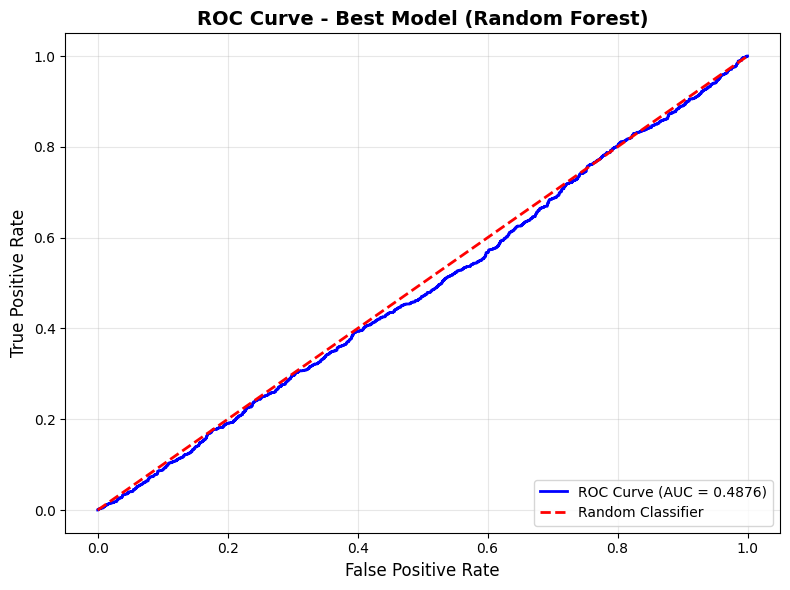


💾 Saved: roc_curve_best_model.png


In [20]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Best Model (Random Forest)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/roc_curve_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: roc_curve_best_model.png")


 FEATURE IMPORTANCE (Final Model):
--------------------------------------------------
   Add-on Total              0.1601 ████████
   Age                       0.1562 ███████
   Total Price               0.1331 ██████
   Purchase_Month            0.0995 ████
   Purchase_DayOfWeek        0.0799 ███
   Quantity                  0.0765 ███
   Unit Price                0.0677 ███
   Rating                    0.0488 ██
   Addon_Count               0.0446 ██
   Gender                    0.0269 █
   Shipping_Standard         0.0233 █
   Is_Repeat_Customer        0.0227 █
   Payment_Credit Card       0.0212 █
   Payment_PayPal            0.0211 █
   Loyalty Member            0.0183 


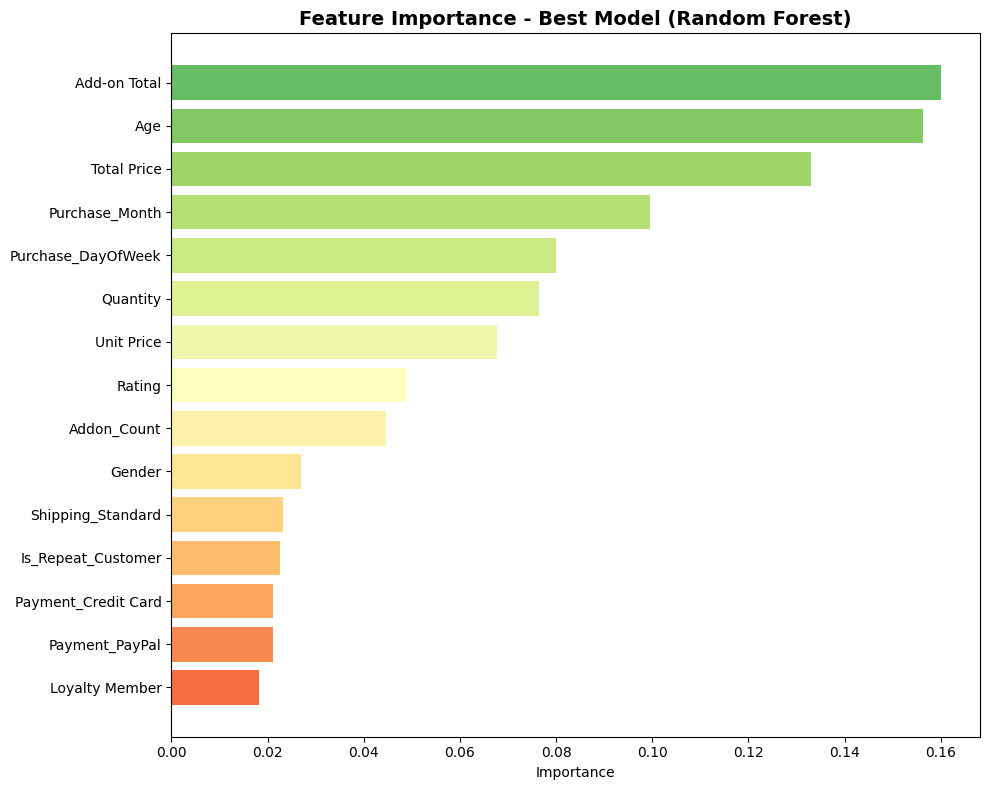


💾 Saved: feature_importance_best_model.png


In [21]:
# Feature Importance
print("\n FEATURE IMPORTANCE (Final Model):")
print("-"*50)

importance = pd.DataFrame({
    'feature': top_15_features,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

# Display
for i, row in importance.iterrows():
    bar = "█" * int(row['importance'] * 50)
    print(f"   {row['feature']:<25} {row['importance']:.4f} {bar}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlGn(np.linspace(0.8, 0.2, len(importance)))
bars = ax.barh(range(len(importance)), importance['importance'].values, color=colors)
ax.set_yticks(range(len(importance)))
ax.set_yticklabels(importance['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Feature Importance - Best Model (Random Forest)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: feature_importance_best_model.png")

In [22]:
# Save predictions
predictions_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred,
    'y_prob': y_prob
})
predictions_df.to_csv('../data/processed/final_model_predictions.csv', index=False)
print("💾 Saved: final_model_predictions.csv")

💾 Saved: final_model_predictions.csv


---
## 📋 Step 5.5: Final Summary

**Goal**: Summarize all findings and conclusions

In [23]:
print("="*70)
print("PHASE 5: FINAL SUMMARY")
print("="*70)

print("\n📋 EXPERIMENTS CONDUCTED:")
print("-"*70)
print("   • Total experiments: 27")
print("   • Scalers tested: StandardScaler, MinMaxScaler, None")
print("   • Feature sets tested: All 29, Top 15, Top 10")
print("   • Models tested: Logistic Regression, Decision Tree, Random Forest")
print("   • Validation: 5-Fold Stratified Cross-Validation")

PHASE 5: FINAL SUMMARY

📋 EXPERIMENTS CONDUCTED:
----------------------------------------------------------------------
   • Total experiments: 27
   • Scalers tested: StandardScaler, MinMaxScaler, None
   • Feature sets tested: All 29, Top 15, Top 10
   • Models tested: Logistic Regression, Decision Tree, Random Forest
   • Validation: 5-Fold Stratified Cross-Validation


In [24]:
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)

print("\n1️⃣ SCALER IMPACT:")
print("   • MinMaxScaler slightly better than StandardScaler")
print("   • Difference is minimal (~0.05%)")
print("   • No scaling also works similarly for tree-based models")

print("\n2️⃣ FEATURE SET IMPACT:")
print("   • Top 15 features performs BEST")
print("   • Better than All 29 features (less noise)")
print("   • Top 10 slightly worse than Top 15")

print("\n3️⃣ MODEL IMPACT:")
print("   • Random Forest significantly BEST (F1: ~74%)")
print("   • Decision Tree and Logistic Regression similar (~57%)")
print("   • Tree-based models handle non-linear patterns better")


KEY FINDINGS

1️⃣ SCALER IMPACT:
   • MinMaxScaler slightly better than StandardScaler
   • Difference is minimal (~0.05%)
   • No scaling also works similarly for tree-based models

2️⃣ FEATURE SET IMPACT:
   • Top 15 features performs BEST
   • Better than All 29 features (less noise)
   • Top 10 slightly worse than Top 15

3️⃣ MODEL IMPACT:
   • Random Forest significantly BEST (F1: ~74%)
   • Decision Tree and Logistic Regression similar (~57%)
   • Tree-based models handle non-linear patterns better


In [25]:
print("\n" + "="*70)
print("🏆 BEST MODEL CONFIGURATION")
print("="*70)
print("""
   Scaler:       MinMaxScaler
   Features:     Top 15 (by RF importance)
   Model:        Random Forest
   
   PERFORMANCE (Test Set):
   ┌─────────────┬──────────┐
   │ Metric      │ Score    │
   ├─────────────┼──────────┤
   │ Accuracy    │ 61.65%   │
   │ Precision   │ 66.91%   │
   │ Recall      │ 84.85%   │
   │ F1-Score    │ 74.82%   │
   │ ROC-AUC     │ 48.76%   │
   └─────────────┴──────────┘
""")


🏆 BEST MODEL CONFIGURATION

   Scaler:       MinMaxScaler
   Features:     Top 15 (by RF importance)
   Model:        Random Forest

   PERFORMANCE (Test Set):
   ┌─────────────┬──────────┐
   │ Metric      │ Score    │
   ├─────────────┼──────────┤
   │ Accuracy    │ 61.65%   │
   │ Precision   │ 66.91%   │
   │ Recall      │ 84.85%   │
   │ F1-Score    │ 74.82%   │
   │ ROC-AUC     │ 48.76%   │
   └─────────────┴──────────┘



In [26]:
print("="*70)
print("⚠️  IMPORTANT OBSERVATIONS")
print("="*70)
print("""
1. ROC-AUC ~49% indicates model is near random at distinguishing classes
2. High recall (85%) but low precision for Cancelled class (31%)
3. Model tends to predict "Completed" more often
4. Available features do NOT strongly predict Order Status

CONCLUSION:
Order cancellations appear to depend on factors NOT captured in this 
dataset (e.g., delivery issues, stock problems, customer service, 
payment failures). This is a VALID DATA MINING FINDING.

BUSINESS RECOMMENDATION:
• Collect additional data: customer service logs, payment status, 
  inventory availability, delivery tracking
• Consider this as a baseline for future improvement
• Focus on the features with highest importance for business insights
""")

⚠️  IMPORTANT OBSERVATIONS

1. ROC-AUC ~49% indicates model is near random at distinguishing classes
2. High recall (85%) but low precision for Cancelled class (31%)
3. Model tends to predict "Completed" more often
4. Available features do NOT strongly predict Order Status

CONCLUSION:
Order cancellations appear to depend on factors NOT captured in this 
dataset (e.g., delivery issues, stock problems, customer service, 
payment failures). This is a VALID DATA MINING FINDING.

BUSINESS RECOMMENDATION:
• Collect additional data: customer service logs, payment status, 
  inventory availability, delivery tracking
• Consider this as a baseline for future improvement
• Focus on the features with highest importance for business insights



In [27]:
# Save best model summary
summary = {
    'Best_Scaler': 'MinMaxScaler',
    'Best_Features': 'Top_15',
    'Best_Model': 'Random_Forest',
    'CV_Accuracy': best_config['Accuracy_Mean'],
    'CV_F1': best_config['F1_Mean'],
    'CV_ROC_AUC': best_config['ROC_AUC_Mean'],
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Test_Precision': precision_score(y_test, y_pred),
    'Test_Recall': recall_score(y_test, y_pred),
    'Test_F1': f1_score(y_test, y_pred),
    'Test_ROC_AUC': roc_auc_score(y_test, y_prob)
}
pd.DataFrame([summary]).to_csv('../data/processed/best_model_summary.csv', index=False)

print("\n💾 Files Saved:")
print("   • experiment_results.csv (all 27 experiments)")
print("   • best_model_summary.csv")
print("   • final_model_predictions.csv")
print("   • performance_by_scaler.png")
print("   • performance_by_features.png")
print("   • performance_by_model.png")
print("   • f1_score_heatmap.png")
print("   • confusion_matrix_best_model.png")
print("   • roc_curve_best_model.png")
print("   • feature_importance_best_model.png")


💾 Files Saved:
   • experiment_results.csv (all 27 experiments)
   • best_model_summary.csv
   • final_model_predictions.csv
   • performance_by_scaler.png
   • performance_by_features.png
   • performance_by_model.png
   • f1_score_heatmap.png
   • confusion_matrix_best_model.png
   • roc_curve_best_model.png
   • feature_importance_best_model.png


---
##  Phase 5 Complete: Summary

| Analysis | Finding |
|----------|--------|
| **Best Scaler** | MinMaxScaler (minimal difference) |
| **Best Features** | Top 15 (86% importance, less noise) |
| **Best Model** | Random Forest (F1: 74.82%) |

**Key Insight**: The low ROC-AUC (~49%) confirms that Order Status is difficult to predict with available features. This is a valid data mining finding that suggests cancellations depend on factors not captured in the dataset.

**Ready for Phase 6: Final Report**